# What makes people want a second date?

Tinder's marketing team is watching the number of matches go down. They want to know **what makes
people interested in each other** — and they have no way to answer that from the app itself, where
all they observe is a swipe with no reason attached.

So they fall back on an experiment. Between 2002 and 2004, Columbia University ran speed dating
events: every participant had a four-minute date with every other participant of the opposite sex,
rated them on six attributes, and secretly said yes or no to a second date. Around it, the
organisers collected questionnaires — what people said they were looking for, before, during and
after the evening.

The value of that dataset is exactly the gap it records: **what people say they want, next to what
they actually pick.**

---

### How this notebook is organised

| Section | What it does |
|---|---|
| 1 | Load the data and establish what one row actually is |
| 2 | Clean it, and state what we deliberately leave dirty |
| 3 | Describe it — distributions, anomalies, correlations |
| 4 | Answer the five questions |
| 5 | What Tinder should take away from it |

Every chart is followed by what it says. Every cleaning decision is followed by its measured
effect.

## 1. Loading the data

The dataset and its official codebook (`Speed+Dating+Data+Key.doc`) both live in `data/`. The
codebook is the reference for every scale used below — several columns look numeric but are coded
categories, and several rating blocks use different scales in different waves.

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.io as pio
from pathlib import Path

# Show every column: the dataset has 195 of them and pandas truncates by default.
pd.set_option('display.max_columns', None)

# Plotly figures are rendered as static images rather than interactive widgets.
# Reason: this notebook is the deliverable and has to stay readable wherever it is opened.
# GitHub, nbviewer and PDF exports all strip interactive plotly output and would show nothing.
pio.renderers.default = 'png'

# Charts are also written to disk, so the README and the oral presentation can reuse them.
IMAGES = Path('images')
IMAGES.mkdir(exist_ok=True)

def show(fig, name):
    """Render a figure in the notebook and save it as a PNG under images/."""
    fig.update_layout(width=980, height=520, template='plotly_white',
                      margin=dict(t=70, b=60, l=70, r=40))
    fig.write_image(IMAGES / f'{name}.png', scale=2)
    fig.show()

In [2]:
df_source = pd.read_csv('data/Speed+Dating+Data.csv', encoding='ISO-8859-1')

# ISO-8859-1 and not UTF-8: the free-text fields (career, field of study, hometown) contain
# characters written on a 2004 Windows machine that are not valid UTF-8.

print(f'{df_source.shape[0]} rows x {df_source.shape[1]} columns')
df_source.head()

8378 rows x 195 columns


,iid,id,gender,idg,condtn,wave,round,position,positin1,order,partner,pid,match,int_corr,samerace,age_o,race_o,pf_o_att,pf_o_sin,pf_o_int,pf_o_fun,pf_o_amb,pf_o_sha,dec_o,attr_o,sinc_o,intel_o,fun_o,amb_o,shar_o,like_o,prob_o,met_o,age,field,field_cd,undergra,mn_sat,tuition,race,imprace,imprelig,from,zipcode,income,goal,date,go_out,career,career_c,sports,tvsports,exercise,dining,museums,art,hiking,gaming,clubbing,reading,tv,theater,movies,concerts,music,shopping,yoga,exphappy,expnum,attr1_1,sinc1_1,intel1_1,fun1_1,amb1_1,shar1_1,attr4_1,sinc4_1,intel4_1,fun4_1,amb4_1,shar4_1,attr2_1,sinc2_1,intel2_1,fun2_1,amb2_1,shar2_1,attr3_1,sinc3_1,fun3_1,intel3_1,amb3_1,attr5_1,sinc5_1,intel5_1,fun5_1,amb5_1,dec,attr,sinc,intel,fun,amb,shar,like,prob,met,match_es,attr1_s,sinc1_s,intel1_s,fun1_s,amb1_s,shar1_s,attr3_s,sinc3_s,intel3_s,fun3_s,amb3_s,satis_2,length,numdat_2,attr7_2,sinc7_2,intel7_2,fun7_2,amb7_2,shar7_2,attr1_2,sinc1_2,intel1_2,fun1_2,amb1_2,shar1_2,attr4_2,sinc4_2,intel4_2,fun4_2,amb4_2,shar4_2,attr2_2,sinc2_2,intel2_2,fun2_2,amb2_2,shar2_2,attr3_2,sinc3_2,intel3_2,fun3_2,amb3_2,attr5_2,sinc5_2,intel5_2,fun5_2,amb5_2,you_call,them_cal,date_3,numdat_3,num_in_3,attr1_3,sinc1_3,intel1_3,fun1_3,amb1_3,shar1_3,attr7_3,sinc7_3,intel7_3,fun7_3,amb7_3,shar7_3,attr4_3,sinc4_3,intel4_3,fun4_3,amb4_3,shar4_3,attr2_3,sinc2_3,intel2_3,fun2_3,amb2_3,shar2_3,attr3_3,sinc3_3,intel3_3,fun3_3,amb3_3,attr5_3,sinc5_3,intel5_3,fun5_3,amb5_3
0,1,1.0,0,1,1,1,10,7,NaN,4,1,11.0,0,0.14,0,27.0,2.0,35.0,20.0,20.0,20.0,0.0,5.0,0,6.0,8.0,8.0,8.0,8.0,6.0,7.0,4.0,2.0,21.0,Law,1.0,NaN,NaN,NaN,4.0,2.0,4.0,Chicago,"60,521","69,487.00",2.0,7.0,1.0,lawyer,NaN,9.0,2.0,8.0,9.0,1.0,1.0,5.0,1.0,5.0,6.0,9.0,1.0,10.0,10.0,9.0,8.0,1.0,3.0,2.0,15.0,20.0,20.0,15.0,15.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,35.0,20.0,15.0,20.0,5.0,5.0,6.0,8.0,8.0,8.0,7.0,NaN,NaN,NaN,NaN,NaN,1,6.0,9.0,7.0,7.0,6.0,5.0,7.0,6.0,2.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,19.44,16.67,13.89,22.22,11.11,16.67,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,7.0,8.0,7.0,6.0,NaN,NaN,NaN,NaN,NaN,1.0,1.0,0.0,NaN,NaN,15.0,20.0,20.0,15.0,15.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
1,1,1.0,0,1,1,1,10,7,NaN,3,2,12.0,0,0.54,0,22.0,2.0,60.0,0.0,0.0,40.0,0.0,0.0,0,7.0,8.0,10.0,7.0,7.0,5.0,8.0,4.0,2.0,21.0,Law,1.0,NaN,NaN,NaN,4.0,2.0,4.0,Chicago,"60,521","69,487.00",2.0,7.0,1.0,lawyer,NaN,9.0,2.0,8.0,9.0,1.0,1.0,5.0,1.0,5.0,6.0,9.0,1.0,10.0,10.0,9.0,8.0,1.0,3.0,2.0,15.0,20.0,20.0,15.0,15.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,35.0,20.0,15.0,20.0,5.0,5.0,6.0,8.0,8.0,8.0,7.0,NaN,NaN,NaN,NaN,NaN,1,7.0,8.0,7.0,8.0,5.0,6.0,7.0,5.0,1.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,19.44,16.67,13.89,22.22,11.11,16.67,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,7.0,8.0,7.0,6.0,NaN,NaN,NaN,NaN,NaN,1.0,1.0,0.0,NaN,NaN,15.0,20.0,20.0,15.0,15.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
2,1,1.0,0,1,1,1,10,7,NaN,10,3,13.0,1,0.16,1,22.0,4.0,19.0,18.0,19.0,18.0,14.0,12.0,1,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,1.0,21.0,Law,1.0,NaN,NaN,NaN,4.0,2.0,4.0,Chicago,"60,521","69,487.00",2.0,7.0,1.0,lawyer,NaN,9.0,2.0,8.0,9.0,1.0,1.0,5.0,1.0,5.0,6.0,9.0,1.0,10.0,10.0,9.0,8.0,1.0,3.0,2.0,15.0,20.0,20.0,15.0,15.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,35.0,20.0,15.0,20.0,5.0,5.0,6.0,8.0,8.0,8.0,7.0,NaN,NaN,NaN,NaN,NaN,1,5.0,8.0,9.0,8.0,5.0,7.0,7.0,NaN,1.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,19.44,16.67,13.89,22.22,11.11,16.67,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,7.0,8.0,7.0,6.0,NaN,NaN,NaN,NaN,NaN,1.0,1.0,0.0,NaN,NaN,15.0,20.0,20.0,15.0,15.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
3,1,1.0,0,1,1,1,10,7,NaN,5,4,14.0,1,0.61,0,23.0,2.0,30.0,5.0,15.0,40.0,5.0,5.0,1,7.0,8.0,9.0,8.0,9

### What is one row?

This is the single most important thing to establish before averaging anything, and it is easy to
get wrong: **one row is one *directed* date, not one couple.**

Every four-minute date produces two rows — one from each side. A row says *"this is how I rated my
partner, and this is what I decided"*. The check below confirms it: every ordered pair
`(participant, partner)` has its mirror image in the data.

A second property matters just as much: **waves were not the same size.** Depending on the evening,
a participant met between 5 and 22 people. Any statistic built on the *rank* of a date within the
evening has to account for that — we come back to it in question 5.

In [3]:
# Confirm the dyadic structure: does every (iid, pid) date have its reciprocal (pid, iid) row?
pairs = set(map(tuple, df_source[['iid', 'pid']].dropna().astype(int).values))
reciprocal = sum(1 for a, b in pairs if (b, a) in pairs)

print(f'rows (directed dates)      : {len(df_source)}')
print(f'distinct (iid, pid) pairs  : {len(pairs)}')
print(f'... of which reciprocal    : {reciprocal}')
print(f'participants               : {df_source["iid"].nunique()}')
print(f'waves                      : {df_source["wave"].nunique()}')

# Dates per participant: this varies by wave and will matter for questions 1 and 5.
dates_per_person = df_source.groupby('iid').size()
print(f'dates per participant      : {dates_per_person.min()} to {dates_per_person.max()}')

print(f'\nsaid yes on               : {df_source["dec"].mean():.1%} of dates')
print(f'ended in a mutual match    : {df_source["match"].mean():.1%} of dates')
print(f'gender split (rows)        : {df_source["gender"].value_counts(normalize=True).round(3).to_dict()}')

rows (directed dates)      : 8378
distinct (iid, pid) pairs  : 8368
... of which reciprocal    : 8368
participants               : 551
waves                      : 21
dates per participant      : 5 to 22

said yes on               : 42.0% of dates
ended in a mutual match    : 16.5% of dates
gender split (rows)        : {1: 0.501, 0: 0.499}


Participants said yes on **42%** of their dates, but only **16.5%** of dates became a mutual match.
That gap is the whole business problem in one line: wanting someone is common, being wanted back at
the same moment is not.

## 2. Cleaning

Four operations, each for a stated reason. Everything else is left exactly as it was found — a
cleaning step that is not justified by a measured problem is a step that quietly invents data.

In [4]:
df = df_source.copy()

# --- 1. Identifiers are labels, not quantities ---------------------------------------------
# iid, id and pid are numeric in the file, which means pandas will happily compute their mean.
# Casting them to string makes that impossible and stops them appearing in any correlation matrix.
for col in ['iid', 'id', 'pid']:
    df[col] = df[col].astype(str)

# --- 2. income is a string ------------------------------------------------------------------
# It is stored as "69,487.00" with a thousands separator, so pandas reads the column as text.
df['income'] = df['income'].str.replace(',', '').astype(float)

# --- 3. Fill a participant's own attributes across their own rows ---------------------------
# age, race and imprace describe the *person*, so they are identical on all of that person's rows.
# If the value were missing on some rows and present on others, propagating it within the
# participant would recover real information without inventing anything. So we try -- and then
# we check what it actually recovered, rather than assuming it worked.
demographics = ['age', 'race', 'imprace']
na_before = df[demographics].isna().sum().sum()
df[demographics] = df.groupby('iid')[demographics].transform(lambda x: x.ffill().bfill())
na_after = df[demographics].isna().sum().sum()
print(f'1. own demographics    : {na_before} missing -> {na_after}  '
      f'({na_before - na_after} recovered)')

# --- 4. Fill the partner's attributes from the partner's own rows ---------------------------
# age_o and race_o are the partner's age and race. The partner is also a participant, so the
# value already exists elsewhere in the table, indexed by their iid. We look it up rather than
# impute it: this is the same fact, read from the row where it was recorded.
lookup_age  = df.groupby('iid')['age'].first()
lookup_race = df.groupby('iid')['race'].first()

na_before = df[['age_o', 'race_o']].isna().sum().sum()
df['age_o']  = df['age_o'].fillna(df['pid'].map(lookup_age))
df['race_o'] = df['race_o'].fillna(df['pid'].map(lookup_race))
na_after = df[['age_o', 'race_o']].isna().sum().sum()
print(f"2. partner's attributes: {na_before} missing -> {na_after}  "
      f"({na_before - na_after} recovered)")

# Neither step recovered anything. Before concluding the code is wrong, check the reason:
# is the value available anywhere else for the rows that are missing it?
available_elsewhere = sum(
    df[df[col].isna()]['iid'].map(df.groupby('iid')[col].apply(lambda s: s.notna().any())).sum()
    for col in demographics)
print(f'\n   rows that could have been filled from another of their own rows: '
      f'{int(available_elsewhere)}')
print(f'   participants concerned by the remaining gaps: '
      f'{df[df[demographics].isna().any(axis=1)]["iid"].nunique()}')

1. own demographics    : 237 missing -> 237  (0 recovered)
2. partner's attributes: 177 missing -> 177  (0 recovered)

   rows that could have been filled from another of their own rows: 0
   participants concerned by the remaining gaps: 9


### Both fills recover exactly zero values — and that is the useful result

Neither step changes a single cell. That is not a bug: the missing demographics belong to **9
participants who never filled the sign-up questionnaire at all**, so there is nothing to propagate
from. And `age_o` / `race_o` are missing on precisely the dates where *those same 9 people* were
the partner — same 9 gaps, seen from the other side.

The code stays because it is the right operation and it is what makes the check possible. What
would have been wrong is running it and assuming it worked: the 111 affected rows survive into
every analysis below, and each one drops them explicitly for the columns it uses.

### What we deliberately do not clean

Two columns are too sparse to be rescued, and filling them would manufacture a result:

- `income` — median household income inferred from a zip code. The codebook says it is empty when
  the participant came from abroad or gave no zip code. That is **not random**: filling it with a
  median would give every foreign student the American median income.
- `expnum` — how many matches the participant expected. Asked in only a few waves.

The ratings themselves keep their missing values too. A participant who wrote nothing in a box was
told to leave it blank if they had not formed an opinion; a median would turn "no opinion" into
"average opinion". Every analysis below drops those rows for the columns it actually uses, and
reports how many are left.

In [5]:
sparse = ['income', 'expnum', 'mn_sat', 'tuition']
print('Columns left untouched, missing rate:')
for col in sparse:
    print(f'  {col:8s} {df[col].isna().mean():5.1%}')

print('\nColumns the analysis relies on, missing rate:')
for col in ['dec', 'match', 'order', 'attr', 'shar', 'int_corr', 'samerace', 'attr1_1', 'attr3_1', 'attr_o']:
    print(f'  {col:8s} {df[col].isna().mean():5.1%}')

Columns left untouched, missing rate:
  income   48.9%
  expnum   78.5%
  mn_sat   62.6%
  tuition  57.2%

Columns the analysis relies on, missing rate:
  dec       0.0%
  match     0.0%
  order     0.0%
  attr      2.4%
  shar     12.7%
  int_corr  1.9%
  samerace  0.0%
  attr1_1   0.9%
  attr3_1   1.3%
  attr_o    2.5%


## 3. Describing the data before questioning it

Three passes, in the order that makes each one interpretable: what the variables look like on
their own, where the data breaks its own rules, and how the variables move together.

### 3.1 The six ratings, one attribute at a time

During the event, each participant rated their partner from 1 to 10 on six attributes. Averages
alone would hide the interesting part, so the chart shows the **whole distribution** and the table
gives the mean *and the variance* — an attribute everyone scores the same way cannot explain why
some dates end in a yes and others do not.

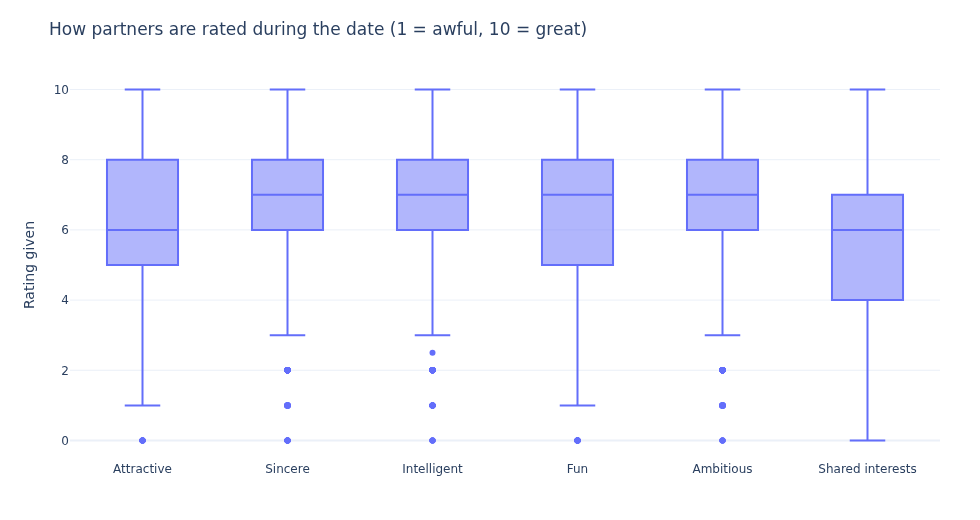

                  mean   var   count
Attractive        6.19  3.80  8176.0
Sincere           7.18  3.03  8101.0
Intelligent       7.37  2.40  8082.0
Fun               6.40  3.82  8028.0
Ambitious         6.78  3.22  7666.0
Shared interests  5.47  4.65  7311.0


In [6]:
SCORECARD = ['attr', 'sinc', 'intel', 'fun', 'amb', 'shar']
LABELS = {'attr': 'Attractive', 'sinc': 'Sincere', 'intel': 'Intelligent',
          'fun': 'Fun', 'amb': 'Ambitious', 'shar': 'Shared interests'}

# Reshape to long format: one row per (date, attribute, score), which is what a box plot needs.
ratings_long = df.melt(value_vars=SCORECARD, var_name='attribute', value_name='score').dropna()
ratings_long['attribute'] = ratings_long['attribute'].map(LABELS)

fig = px.box(ratings_long, x='attribute', y='score',
             title='How partners are rated during the date (1 = awful, 10 = great)',
             labels={'attribute': '', 'score': 'Rating given'})
show(fig, '3_1_rating_distributions')

# Mean and variance side by side: the mean says how generous people are, the variance says how
# much they disagree -- and only the second can drive a decision.
summary = df[SCORECARD].agg(['mean', 'var', 'count']).T
summary.index = summary.index.map(LABELS)
print(summary.round(2).to_string())

**Reading it.** People are generous on the attributes that are hard to disprove in four minutes —
intelligence (7.4) and sincerity (7.2) — and much more reserved on the ones they feel qualified to
judge: shared interests (5.5) and attractiveness (6.2).

The variances point the same way. Intelligence has the *lowest* spread of the six: everybody scores
everybody around 7, so the column carries almost no information about who gets a yes. Shared interests has
the widest spread (4.65), with fun and attractiveness just behind (3.82 and 3.80). Before running a single correlation, this already tells
us which attributes *can* explain a decision, and which are too uniform to explain anything.

### 3.2 Anomaly detection: where the data breaks its own rules

Three rules come from the codebook, and all three are broken somewhere in the file. Finding out
*how often* decides whether we correct, drop, or leave alone.

In [7]:
POINTS_1_1 = ['attr1_1', 'sinc1_1', 'intel1_1', 'fun1_1', 'amb1_1', 'shar1_1']

# Rule 1 -- the *1_1 block is a budget: "You have 100 points to distribute". Does it sum to 100?
budget = df.drop_duplicates('iid')[POINTS_1_1].sum(axis=1)
print('Rule 1 -- the 100-point budget, one row per participant')
print(f'  sums to exactly 100 : {(budget.round(0) == 100).sum():3d} participants')
print(f'  sums to 0 (blank)   : {(budget == 0).sum():3d}')
print(f'  sums to something else: {((budget != 0) & (budget.round(0) != 100)).sum():3d} '
      f'-> {sorted(budget[(budget != 0) & (budget.round(0) != 100)].round(0).unique())}')

# Rule 2 -- the scorecard is a 1-10 scale. Anything above 10 is a filling error.
print('\nRule 2 -- ratings above the 1-10 ceiling')
partner_cols = ['attr_o', 'sinc_o', 'intel_o', 'fun_o', 'amb_o', 'shar_o']
over = {c: (df[c] > 10).sum() for c in SCORECARD + partner_cols}
print('  ' + str({k: v for k, v in over.items() if v}) + '  (all other columns: none)')

# Rule 3 -- the codebook says waves 6-9 used a 1-10 scale instead of the 100-point budget.
print('\nRule 3 -- do waves 6-9 really use a different scale?')
print(df.drop_duplicates('iid').assign(total=budget)
        .groupby(df.drop_duplicates('iid')['wave'].between(6, 9))['total']
        .agg(['median', 'min', 'max']).rename(index={False: 'waves 1-5, 10-21', True: 'waves 6-9'})
        .round(1).to_string())

Rule 1 -- the 100-point budget, one row per participant
  sums to exactly 100 : 534 participants
  sums to 0 (blank)   :   7
  sums to something else:  10 -> [np.float64(90.0), np.float64(95.0), np.float64(101.0), np.float64(110.0), np.float64(120.0), np.float64(148.0)]

Rule 2 -- ratings above the 1-10 ceiling
  {'attr_o': np.int64(1), 'fun_o': np.int64(1)}  (all other columns: none)

Rule 3 -- do waves 6-9 really use a different scale?
                  median  min    max
wave                                
waves 1-5, 10-21   100.0  0.0  148.0
waves 6-9          100.0  0.0  100.0


**What we do with each.**

- **The budget** is respected by 534 of the 551 participants. Ten wrote sums of 90, 95, 101, 110,
  120 or 148, and seven left the block blank. Rescaling each participant to 100 fixes the first
  group and produces a missing value for the second — which is the honest outcome, since a blank
  block is not an opinion.
- **Ratings above 10** exist on exactly two columns, one row each (`attr_o` at 10.5, `fun_o` at 11).
  Capping at 10 is safe at that volume.
- **The waves 6-9 scale is a documentation trap.** The codebook describes the *questionnaire*, where
  those waves were asked to rate 1-10. But in this file the values have already been converted to
  the 100-point scale by whoever assembled the dataset — the giveaway is the decimals (6.67, 8.33,
  11.11 = 1-10 answers divided by their own total). Both groups sit at a median of exactly 100.
  **There is no scale to correct here**, and code written to "fix waves 6-9" would be correcting a
  problem that does not exist.

### 3.3 Pearson correlation matrix

Now that we know what the variables look like, we can look at how they move together. Two things
to read here, and the second is the one that shapes the rest of the notebook.

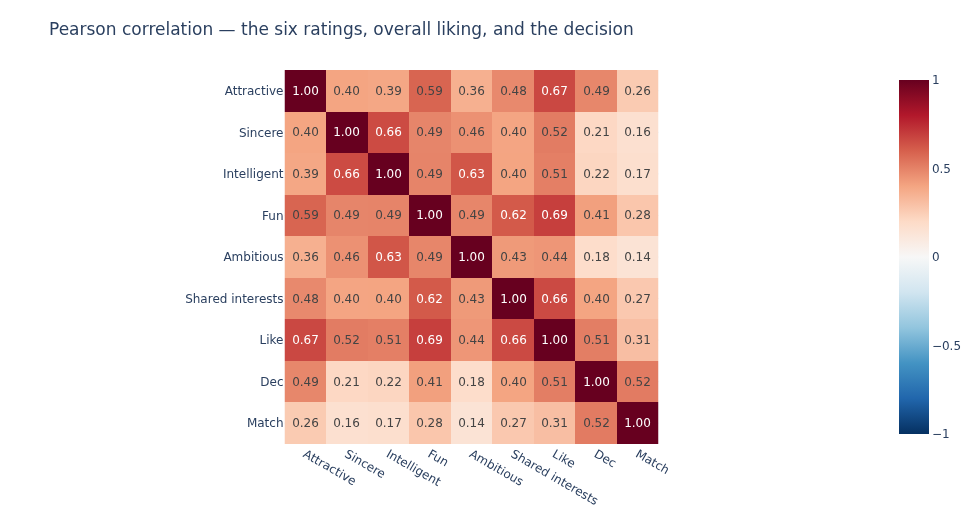

In [8]:
corr_cols = SCORECARD + ['like', 'dec', 'match']
corr = df[corr_cols].corr(method='pearson')
corr.index = corr.columns = [LABELS.get(c, c.capitalize()) for c in corr_cols]

fig = px.imshow(corr, text_auto='.2f', color_continuous_scale='RdBu_r', zmin=-1, zmax=1,
                title='Pearson correlation — the six ratings, overall liking, and the decision')
show(fig, '3_3_correlation_matrix')

**Reading it — the top-left block.** The six attributes are all positively correlated *with each
other*, between +0.36 and +0.66. That is the **halo effect**: they were all ticked on the same card,
in the same four minutes, by someone who had already formed a general impression. A participant who
enjoyed the conversation rates everything high, including intelligence they had no way to assess.

This is not a detail — it is a constraint on what the rest of the notebook can claim. Any variable
rated *during* the date is contaminated by the outcome of the date. Whenever a question can be
answered with a variable measured *before* the event instead, that variable is the more trustworthy
one. Question 3 is built entirely on this distinction.

**Reading it — the decision column.** Attractiveness (+0.49), fun (+0.41) and shared interests
(+0.40) move with the decision. Sincerity (+0.21), intelligence (+0.22) and ambition (+0.18) barely
do — exactly the three attributes that section 3.1 showed everyone scores the same way.

---

# 4. The five questions

## Question 1 — What are the least desirable attributes in a partner? Does it differ by gender?

This asks what people *say* they want, so it uses the pre-event questionnaire: 100 points to
distribute across the six attributes, the more points the more important.

Two methodological points, both of which change the numbers:

1. **The answer belongs to a participant, not to a date.** It is copied onto every row of that
   participant, so averaging over rows would give someone who had 22 dates four times the weight of
   someone who had 5. We deduplicate to one row per participant first.
2. **We rescale each participant to 100 points**, which repairs the handful of budgets found in
   section 3.2 that summed to 90, 110, 120 or 148, and turns blank blocks into missing values.

The event also asked the same question again halfway through the evening (`*1_s`), on a 1-10 scale.
Plotting both shows whether meeting real people changes what you claim to want.

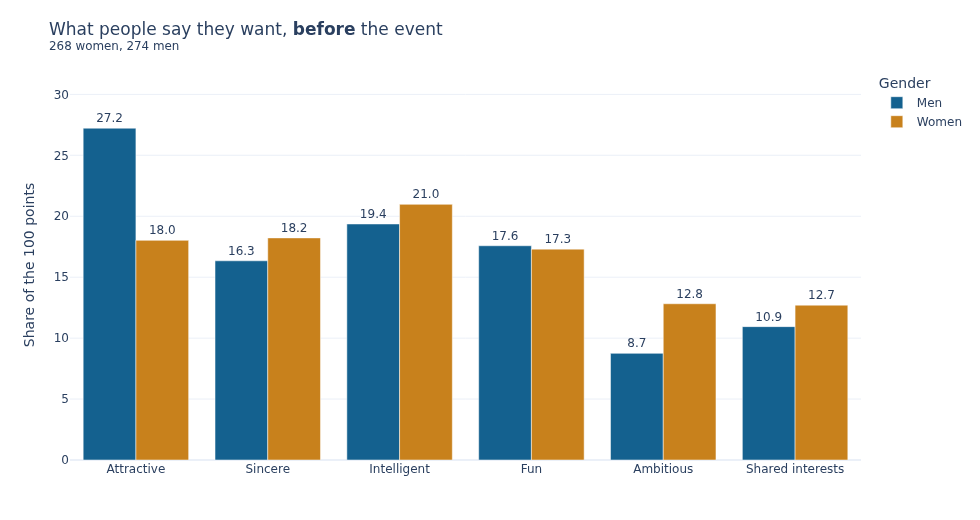

attribute  Ambitious  Attractive   Fun  Intelligent  Shared interests  Sincere
Gender                                                                        
Men              8.7        27.2  17.6         19.4              10.9     16.3
Women           12.8        18.0  17.3         21.0              12.7     18.2


In [9]:
POINTS_1_S = ['attr1_s', 'sinc1_s', 'intel1_s', 'fun1_s', 'amb1_s', 'shar1_s']

# One row per participant: their stated preferences are a property of the person.
people = df.drop_duplicates('iid').copy()

def as_shares(frame, cols):
    """Rescale each row of `cols` so it sums to 100, and return it as percentages.

    Legitimate here, and only here: the codebook defines these blocks as a budget to be split
    across the six attributes, so the share IS the quantity the question asks about. Rows that
    were left blank sum to 0 and become NaN, which is the correct outcome for "no answer".
    """
    total = frame[cols].sum(axis=1).replace(0, np.nan)
    return frame[cols].div(total, axis=0) * 100

people[POINTS_1_1] = as_shares(people, POINTS_1_1)
people[POINTS_1_S] = as_shares(people, POINTS_1_S)
people['Gender'] = people['gender'].map({0: 'Women', 1: 'Men'})

def preference_chart(cols, title, filename):
    long = people.melt(id_vars='Gender', value_vars=cols,
                       var_name='attribute', value_name='share').dropna()
    # 'attr1_1' -> 'attr' -> 'Attractive': strip the questionnaire suffix, keep the attribute.
    long['attribute'] = long['attribute'].str.split('1_').str[0].map(LABELS)

    n = long.groupby('Gender')['share'].count() // len(cols)

    # plotly express draws one bar per row and stacks them, so the mean has to be computed
    # here rather than left to the chart.
    means = long.groupby(['Gender', 'attribute'], as_index=False)['share'].mean()

    fig = px.bar(means, x='attribute', y='share', color='Gender', barmode='group', text='share',
                 category_orders={'attribute': list(LABELS.values())},
                 color_discrete_map={'Women': '#C8811C', 'Men': '#14618F'},
                 labels={'attribute': '', 'share': 'Share of the 100 points'},
                 title=f'{title}<br><sup>{n.get("Women", 0)} women, {n.get("Men", 0)} men</sup>')
    fig.update_traces(texttemplate='%{text:.1f}', textposition='outside')
    fig.update_yaxes(range=[0, 32])
    show(fig, filename)
    return long.groupby(['Gender', 'attribute'])['share'].mean().unstack()

before = preference_chart(POINTS_1_1, 'What people say they want, <b>before</b> the event',
                          '4_1_declared_before')
print(before.round(1).to_string())

280 participants answered both, across 12 of the 21 waves:

                  Before the event  Halfway through  Change
Shared interests              12.4             13.5     1.1
Ambitious                     11.4             12.2     0.8
Attractive                    21.3             22.0     0.7
Sincere                       17.6             17.0    -0.6
Fun                           17.5             16.7    -0.8
Intelligent                   19.8             18.6    -1.2


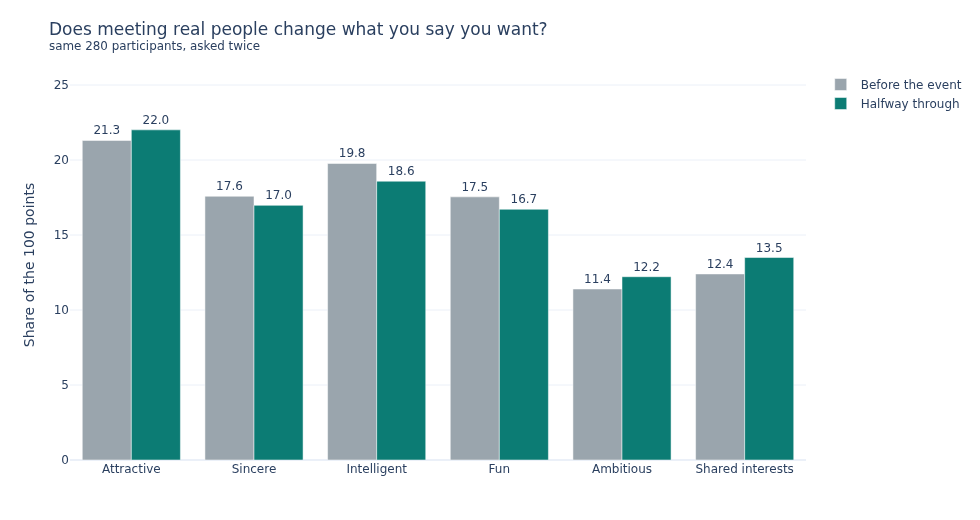

In [10]:
# The mid-event questionnaire (*1_s) was run in only 12 of the 21 waves. Comparing its average to
# the pre-event average would compare two different groups of people and call the difference a
# change. The shift is only meaningful on the participants who answered *both*.
paired = people.dropna(subset=POINTS_1_1 + POINTS_1_S)

shift = pd.DataFrame({'Before the event': paired[POINTS_1_1].mean().values,
                      'Halfway through':  paired[POINTS_1_S].mean().values},
                     index=list(LABELS.values()))
shift['Change'] = shift['Halfway through'] - shift['Before the event']

print(f'{len(paired)} participants answered both, across '
      f'{paired["wave"].nunique()} of the 21 waves:\n')
print(shift.round(1).sort_values('Change', ascending=False).to_string())

plot = (shift[['Before the event', 'Halfway through']].reset_index(names='attribute')
        .melt(id_vars='attribute', var_name='moment', value_name='share'))
fig = px.bar(plot, x='attribute', y='share', color='moment', barmode='group',
             category_orders={'attribute': list(LABELS.values())},
             color_discrete_map={'Before the event': '#9AA5AD', 'Halfway through': '#0C7C74'},
             labels={'attribute': '', 'share': 'Share of the 100 points', 'moment': ''},
             text='share',
             title='Does meeting real people change what you say you want?'
                   f'<br><sup>same {len(paired)} participants, asked twice</sup>')
fig.update_traces(texttemplate='%{text:.1f}', textposition='outside')
fig.update_yaxes(range=[0, 26])
show(fig, '4_1_declared_midway')

**For men the least desirable attribute is ambition, clearly: 8.7 points out of 100**, well below
shared interests (10.9). **For women there is no single answer** — ambition (12.8) and shared
interests (12.7) are separated by a tenth of a point, which is nothing. So the honest reply is:
ambition for men, a tie between ambition and shared interests for women.

**The genders differ on one attribute, not on six.** Men give attractiveness 27.2 points against
18.0 for women — a nine-point gap, and the largest number in the whole table. Take attractiveness
out and the two rankings are nearly identical: intelligence, then sincerity, then fun, then the
ambition / shared-interests tie. The popular framing of "men and women want different things" is,
in this data, one attribute wide.

**Halfway through the evening, the declared preferences move — and not toward the obvious answer.**
On the 280 participants asked twice, shared interests gain 1.1 points and ambition 0.8, while
intelligence loses 1.2 and fun 0.8. Attractiveness barely moves (+0.7). Nobody had been shown their
results, so this is what four minutes of practice does to an opinion formed in the abstract: the
abstract-sounding criteria give way to the ones you can actually observe in a conversation.

It is also the first sign that the pre-event answers are not a stable description of what people
want — let alone of what they do. That is what question 2 tests.

## Question 2 — How important do people *think* attractiveness is, versus its real impact?

The two halves of this question are not measured on the same scale, and that is the whole
difficulty:

- **What people think** is a share of a 100-point budget (`attr1_1`).
- **The real impact** is how much an attribute moves the yes/no decision.

The instinct is to rescale one onto the other. It is the wrong move, for two reasons.

**A correlation is already scale-free.** Multiplying a rating by 1000 or shifting it by 7 leaves
`corr(attribute, decision)` unchanged — it always lives in [-1, 1]. There is nothing to normalise.

**And rescaling each row by its own total is not a change of scale, it is a change of variable.**
A change of scale applies the same factor to every row. Dividing each row by *its own* sum does not:
someone who rates every partner 8/8/8/8/8/8 and someone who rates every partner 2/2/2/2/2/2 become
identical, and the six shares are then forced to sum to 100 — so when attractiveness goes up, the
five others must mechanically go down. That constraint manufactures negative correlations for
sincerity, intelligence and ambition that have nothing to do with sincerity, intelligence or
ambition. The cell below measures both, side by side, so the artefact is visible rather than
asserted.

The right comparison is therefore: **the declared budget, against the correlation computed on raw
ratings.**

In [11]:
rated = df.dropna(subset=SCORECARD + ['dec'])

# The artefact, measured rather than claimed: same data, with and without row normalisation.
shares = rated[SCORECARD].div(rated[SCORECARD].sum(axis=1), axis=0) * 100
artefact = pd.DataFrame({
    'corr on raw ratings':        {c: rated[c].corr(rated['dec']) for c in SCORECARD},
    'corr on row-normalised':     {c: shares[c].corr(rated['dec']) for c in SCORECARD},
})
artefact.index = artefact.index.map(LABELS)
print('Why we do not normalise the scorecard before correlating:')
print(artefact.round(3).to_string())
print('\n-> three of the six flip sign. The scorecard is a 1-10 rating, not a budget.')

Why we do not normalise the scorecard before correlating:
                  corr on raw ratings  corr on row-normalised
Attractive                      0.487                   0.249
Sincere                         0.208                  -0.223
Intelligent                     0.215                  -0.287
Fun                             0.412                   0.185
Ambitious                       0.185                  -0.209
Shared interests                0.401                   0.236

-> three of the six flip sign. The scorecard is a 1-10 rating, not a budget.


In [12]:
# Computed separately for each gender. Question 1 found a nine-point gap between men and women on
# attractiveness alone -- pooling them would average that away and hide the answer.
def declared_vs_real(gender_code, gender_name):
    declared = people[people['gender'] == gender_code][POINTS_1_1].mean()
    declared.index = list(LABELS.values())

    sub = rated[rated['gender'] == gender_code]
    real = pd.Series({LABELS[c]: sub[c].corr(sub['dec']) for c in SCORECARD})

    table = pd.DataFrame({'Declared (points)': declared, 'Real impact (corr)': real})
    table['Rank declared'] = table['Declared (points)'].rank(ascending=False).astype(int)
    table['Rank real']     = table['Real impact (corr)'].rank(ascending=False).astype(int)
    table['Gap']           = table['Rank declared'] - table['Rank real']
    return table.assign(Gender=gender_name).sort_values('Rank real')

comparison = pd.concat([declared_vs_real(1, 'Men'), declared_vs_real(0, 'Women')])

for gender in ['Men', 'Women']:
    print(f'--- {gender} ---')
    print(comparison[comparison['Gender'] == gender]
          .drop(columns='Gender').round(3).to_string(), '\n')

--- Men ---
                  Declared (points)  Real impact (corr)  Rank declared  Rank real  Gap
Attractive                   27.225               0.517              1          1    0
Fun                          17.579               0.403              3          2    1
Shared interests             10.943               0.388              5          3    2
Ambitious                     8.749               0.214              6          4    2
Intelligent                  19.366               0.211              2          5   -3
Sincere                      16.344               0.187              4          6   -2 

--- Women ---
                  Declared (points)  Real impact (corr)  Rank declared  Rank real  Gap
Attractive                   18.022               0.443              3          1    2
Fun                          17.301               0.417              4          2    2
Shared interests             12.703               0.412              6          3    3
Intelligent    

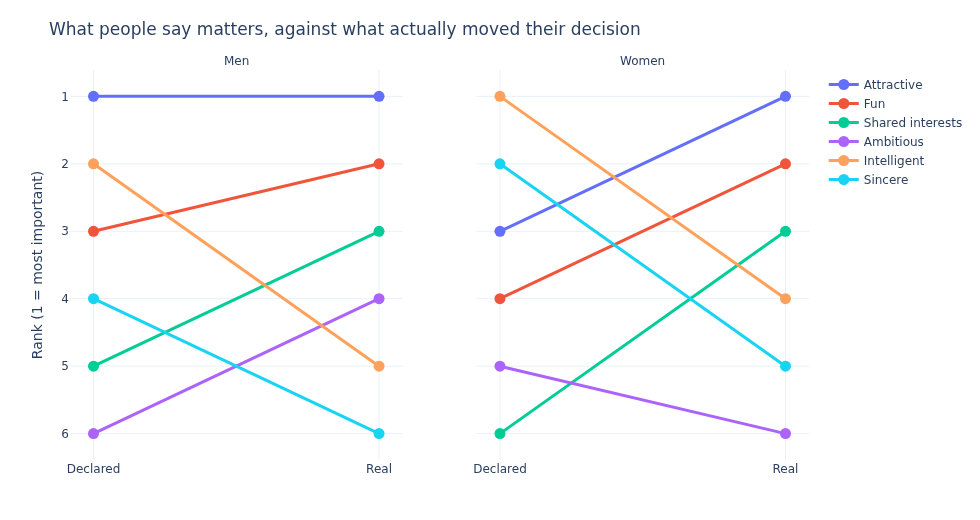

In [13]:
# Both columns are ranks on the same 1-6 scale, so a slope chart puts them on one axis:
# a line going down means the attribute matters less in practice than people claimed.
ranks = (comparison.reset_index(names='attribute')
         .melt(id_vars=['attribute', 'Gender'], value_vars=['Rank declared', 'Rank real'],
               var_name='measure', value_name='rank'))

ranks['measure'] = ranks['measure'].str.replace('Rank ', '').str.capitalize()

fig = px.line(ranks, x='measure', y='rank', color='attribute', facet_col='Gender', markers=True,
              facet_col_spacing=0.10,
              category_orders={'measure': ['Declared', 'Real'], 'Gender': ['Men', 'Women']},
              labels={'measure': '', 'rank': 'Rank (1 = most important)', 'attribute': ''},
              title='What people say matters, against what actually moved their decision')
fig.update_yaxes(autorange='reversed', dtick=1)
fig.update_traces(line_width=3, marker_size=11)
fig.for_each_annotation(lambda a: a.update(text=a.text.split('=')[-1]))
show(fig, '4_2_declared_vs_real')

**Men are honest about attractiveness. Women are not.** Men rank it first out of six when asked in
the abstract, and it comes out first in their decisions — a gap of zero. Women rank it **third**
(18.0 points, behind intelligence and sincerity) and it comes out **first** in theirs, and by the
widest margin of any attribute they rate (+0.44). Splitting by gender is what makes this visible;
pooled together the two cancel out and the gap disappears entirely.

**Intelligence is the mirror image, for both.** Declared first by women and second by men, it lands
fourth and fifth in practice. Sincerity follows the same path. These are the socially respectable
answers — and section 3.1 already showed why they cannot work: everyone is rated around 7 on
intelligence, so the column has no room left to separate a yes from a no.

**Ambition is the one place the genders diverge again.** Men declare it last (8.7 points) and it
still lands fourth in their decisions — they use it more than they admit. For women it is declared
fifth and lands sixth.

**The gap is not proof that people lie.** A four-minute date gives you very little to judge on:
attractiveness is available immediately, ambition is not. People may genuinely value intelligence
and be unable to act on it in the time given. What the data supports is the narrower statement:
**what people declare is a poor predictor of what they do**, whatever the reason.

In [14]:
# Cross-check on an independent measurement, and one we do not have to transform.
# attr7_2 asks participants, the day after: "think back to your yes/no decisions, distribute
# 100 points reflecting the ACTUAL importance of these attributes in your decisions".
# Same 100-point scale as attr1_1 by construction, so the two are directly comparable.
POINTS_7_2 = ['attr7_2', 'sinc7_2', 'intel7_2', 'fun7_2', 'amb7_2', 'shar7_2']

# Paired again: both columns are read on the same participants, so the difference is a change
# of mind and not a difference between whoever happened to answer each questionnaire.
retrospective = people.dropna(subset=POINTS_7_2 + POINTS_1_1).copy()
retrospective[POINTS_7_2] = as_shares(retrospective, POINTS_7_2)

cross_check = pd.DataFrame({
    'Declared before': retrospective[POINTS_1_1].mean().set_axis(list(LABELS.values())),
    'Reported after':  retrospective[POINTS_7_2].mean().set_axis(list(LABELS.values())),
})
cross_check['Change'] = cross_check['Reported after'] - cross_check['Declared before']
print(f'Cross-check on the {retrospective["iid"].nunique()} participants who answered '
      f'the day-after questionnaire (out of {people["iid"].nunique()}):\n')
print(cross_check.round(1).sort_values('Change', ascending=False).to_string())

Cross-check on the 123 participants who answered the day-after questionnaire (out of 551):

                  Declared before  Reported after  Change
Attractive                   23.9            32.2     8.3
Shared interests             11.7            12.1     0.4
Fun                          18.1            18.4     0.3
Ambitious                     9.2             7.4    -1.8
Sincere                      17.0            14.2    -2.8
Intelligent                  20.1            15.8    -4.4


**Two independent methods, one conclusion.** The correlation approach and participants' own
retrospective accounting both put attractiveness far above where it was declared — here **+8.3
points** of budget, by far the largest move of the six, while intelligence (−4.4), sincerity (−2.8)
and ambition (−1.8) all fall.

Note the sample: only 123 of the 551 participants filled the day-after questionnaire, and the ones
who bother to answer a follow-up are not necessarily a random sample. This is a confirmation of the
main result, not a replacement for it.

## Question 3 — Are shared interests more important than a shared racial background?

The obvious way to answer is to correlate both with the decision. Doing that produces a clear
result — and the wrong one.

The problem is that the two candidates are not measured the same way. `samerace` is a **fact**,
fixed before anyone walked into the room. `shar` is a **perception**, ticked on the same card, in
the same four minutes, as the decision it is being compared to — and section 3.3 showed the whole
card moves together under the halo effect.

The dataset offers a way out. `int_corr` is the correlation between the two participants' interest
profiles, computed from the seventeen activities they each rated **before the event** (sports,
museums, reading, clubbing…). It measures the same idea as `shar` — do these two people like the
same things — but as a fact, established in advance, exactly like `samerace`.

So we compute all three, and keep them side by side.

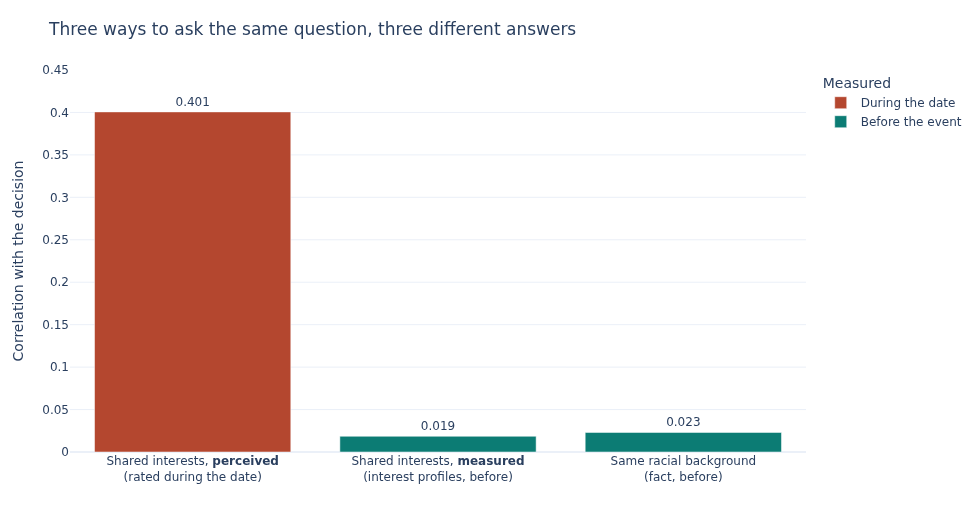

                                             predictor  correlation    n
   Shared interests, perceived (rated during the date)        0.401 7311
Shared interests, measured (interest profiles, before)        0.019 8220
                 Same racial background (fact, before)        0.023 8378


In [15]:
predictors = {
    'shar':     'Shared interests, <b>perceived</b><br>(rated during the date)',
    'int_corr': 'Shared interests, <b>measured</b><br>(interest profiles, before)',
    'samerace': 'Same racial background<br>(fact, before)',
}

rows = []
for col, label in predictors.items():
    sub = df.dropna(subset=[col, 'dec'])
    rows.append({'predictor': label,
                 'correlation': sub[col].corr(sub['dec']),
                 'when': 'During the date' if col == 'shar' else 'Before the event',
                 'n': len(sub)})
strength = pd.DataFrame(rows)

fig = px.bar(strength, x='predictor', y='correlation', color='when', text='correlation',
             color_discrete_map={'During the date': '#B4472F', 'Before the event': '#0C7C74'},
             labels={'predictor': '', 'correlation': 'Correlation with the decision', 'when': 'Measured'},
             title='Three ways to ask the same question, three different answers')
fig.update_traces(texttemplate='%{text:.3f}', textposition='outside')
fig.update_yaxes(range=[0, 0.45])
show(fig, '4_3_interests_vs_race')

print(strength[['predictor', 'correlation', 'n']].assign(
    predictor=lambda d: d['predictor'].str.replace('<br>', ' ').str.replace(r'</?b>', '', regex=True)
).round(3).to_string(index=False))

**Compared naively, shared interests crush racial background — by a factor of seventeen** (+0.401
against +0.023). That is the answer most analyses of this dataset stop at.

**Compared fairly, both are worth nothing.** Put the two *pre-event facts* next to each other and
actually having interests in common (+0.019) predicts a second date no better than sharing a racial
background (+0.023) — and marginally worse. Neither is a meaningful predictor.

**So the answer depends on which measurement you accept, and that is the finding.** What predicts a
yes is not whether two people genuinely have things in common. It is whether one of them *came away
thinking so*. The perception is worth 0.40; the underlying fact is worth 0.02.

That distinction survives one obvious objection. Yes, some of the 0.40 is halo — you liked them, so
you ticked everything high. But the gap between 0.40 and 0.02 is far too large to be halo alone: if
perceived common ground were just a reflection of real common ground plus noise, the two numbers
could not be twenty times apart.

**And this is the actionable one for Tinder.** A racial background cannot be changed and, on this
evidence, should not be a matching signal — it predicts nothing. A declared interest list barely
predicts anything either. What predicts a second date is the feeling of connection that forms during
the conversation, which means the product lever is not better filtering upstream. It is whatever
helps two people *discover* common ground once they are talking.

### Does that hold once we account for how much people simply liked each other?

A fair objection to the paragraph above: `shar` might just be a proxy for the overall impression.
The check below compares the raw correlation with the **partial correlation**, holding the general
liking score (`like`) constant — that is, asking how much shared interests still explain *between
two dates the participant liked equally.*

In [16]:
def partial_corr(frame, x, y, control):
    """Correlation between x and y once `control` is removed from both.

    Each variable is regressed on the control, and we correlate what is left over. If shared
    interests only mattered through the general impression, the residuals would be uncorrelated.
    """
    sub = frame.dropna(subset=[x, y, control])
    residual = {}
    for col in (x, y):
        slope, intercept = np.polyfit(sub[control], sub[col], 1)
        residual[col] = sub[col] - (slope * sub[control] + intercept)
    return np.corrcoef(residual[x], residual[y])[0, 1], len(sub)

print(f'{"predictor":10s} {"raw corr":>10s} {"controlling for liking":>24s}')
for col in ['shar', 'int_corr', 'samerace']:
    sub = df.dropna(subset=[col, 'dec'])
    raw = sub[col].corr(sub['dec'])
    partial, n = partial_corr(df, col, 'dec', 'like')
    print(f'{col:10s} {raw:>+10.3f} {partial:>+24.3f}   (n={n})')

predictor    raw corr   controlling for liking
shar           +0.401                   +0.095   (n=7285)
int_corr       +0.019                   -0.002   (n=7996)
samerace       +0.023                   -0.000   (n=8138)


Holding the overall impression constant, perceived shared interests drop sharply — most of that
+0.40 really was the general feeling about the person, as the halo effect predicted. But it does not
drop to zero, and it stays above both pre-event facts, which barely move because they were never
entangled with the impression in the first place.

The conclusion holds, in a more careful form: **shared interests matter mainly as a component of
liking someone, not as an independent criterion — and the objective version of them does not matter
at all.**

## Question 4 — Can people accurately predict their own value on the dating market?

Before the event, participants rated themselves 1-10 on five attributes (`*3_1`, *"how do you think
you measure up?"*). During the event, their partners rated them on the same scale (`*_o`).

The comparison is therefore **self-assessment minus average rating received**, one number per
participant:

- **positive** → they thought better of themselves than their dates did
- **zero** → accurate
- **negative** → they underestimated themselves

Two precautions. The average received is computed per participant, so someone with 22 dates counts
once, like someone with 5. And the handful of out-of-range ratings found in section 3.2 are capped
at 10 before averaging.

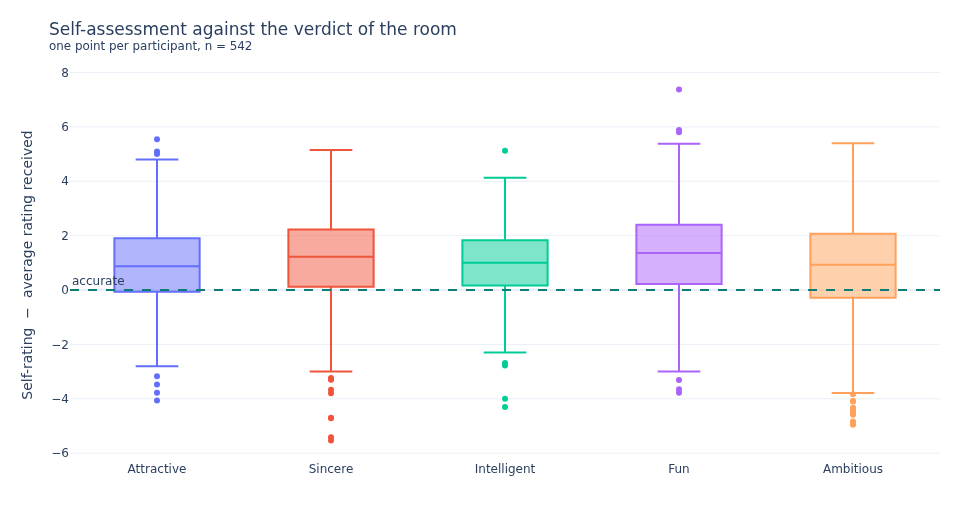

        Attractive  Sincere  Intelligent   Fun  Ambitious
mean          0.90     1.07         0.99  1.27       0.76
median        0.88     1.22         1.00  1.36       0.93
std           1.54     1.58         1.23  1.59       1.83

Participants who overestimated themselves on attractiveness: 72.1%


In [17]:
SELF     = ['attr3_1', 'sinc3_1', 'intel3_1', 'fun3_1', 'amb3_1']
RECEIVED = ['attr_o', 'sinc_o', 'intel_o', 'fun_o', 'amb_o']

judged = df.copy()
# Cap the two columns that exceeded the 1-10 ceiling (attr_o at 10.5, fun_o at 11).
judged[RECEIVED] = judged[RECEIVED].clip(upper=10)

# One row per participant: their own rating, and the mean of what their partners gave them.
self_view     = judged.groupby('iid')[SELF].first()
received_view = judged.groupby('iid')[RECEIVED].mean()

gap = pd.DataFrame(index=self_view.index)
for self_col, received_col in zip(SELF, RECEIVED):
    attribute = LABELS[self_col.replace('3_1', '')]
    gap[attribute] = self_view[self_col] - received_view[received_col]

gap_long = gap.melt(var_name='attribute', value_name='gap').dropna()

fig = px.box(gap_long, x='attribute', y='gap', color='attribute',
             labels={'attribute': '', 'gap': 'Self-rating  −  average rating received'},
             title='Self-assessment against the verdict of the room'
                   f'<br><sup>one point per participant, n = {gap.dropna(how="all").shape[0]}</sup>')
fig.add_hline(y=0, line_dash='dash', line_color='#0C7C74', line_width=2,
              annotation_text='accurate', annotation_position='top left')
fig.update_layout(showlegend=False)
show(fig, '4_4_self_assessment_gap')

print(gap.agg(['mean', 'median', 'std']).round(2).to_string())
print(f'\nParticipants who overestimated themselves on attractiveness: '
      f'{(gap["Attractive"] > 0).mean():.1%}')

**No — and the error goes in one direction, on every attribute.** All five boxes sit above the
accuracy line. The median participant rates themselves roughly **one point higher** than the room
does, on a 1-10 scale. On attractiveness, **72% overestimate themselves.**

**The bias is strikingly uniform.** The mean gaps run from +0.76 (ambition) to +1.27 (fun) — a
range of half a point across five very different attributes. This is not a population that
misjudges specific traits; it is a population that is generally generous with itself.

It is tempting to expect the illusion to be largest on the attributes a stranger cannot verify in
four minutes. **The data does not support that.** Ambition is arguably the hardest of the five to
judge on a first date and it carries the *smallest* gap; fun is among the easiest and carries the
largest. Whatever drives the bias, it is not the availability of evidence.

**And the spread matters more than the average.** The standard deviations (1.2 to 1.8) are larger
than the bias itself, and the whiskers reach past ±4 points. The interesting population is not the
average participant who is off by one — it is the tails, who are wrong by four in both directions.

*A note on the measurement.* `*3_1` asks for the participant's own opinion of themselves. The
dataset also has `*5_1`, which asks the more literal question — *how do you think others perceive
you?* We use `*3_1` because 542 of 551 participants answered it, against 314 for `*5_1`.

## Question 5 — Is it better to be someone's first date of the night, or their last?

The tempting approach is to average the decision by `order` — the rank of the date within the
evening — and read the curve. It produces a clean downward slope that looks like fatigue setting in.

**That slope cannot be trusted, because `order` does not mean the same thing in every wave.**
Participants met between 5 and 22 people. So `order = 20` exists only in the longest evenings: the
left of the curve describes all 551 participants, the right describes a handful from one wave. Any
decline could be fatigue, or it could simply be that the people still present at rank 20 are a
different, pickier crowd. The two effects are impossible to separate.

The first cell measures how fast the population thins out.

In [18]:
timed = df.dropna(subset=['dec', 'order', 'round'])

coverage = timed.groupby('order').agg(mean_dec=('dec', 'mean'),
                                      participants=('iid', 'nunique'),
                                      waves=('wave', 'nunique'))
print(coverage.round(3).to_string())
print(f'\n-> order 1 covers all {coverage["participants"].iloc[0]} participants and '
      f'{coverage["waves"].iloc[0]} waves;')
print(f'   order {coverage.index[-1]} covers {coverage["participants"].iloc[-1]} participants '
      f'from {coverage["waves"].iloc[-1]} wave.')

       mean_dec  participants  waves
order                               
1         0.499           551     21
2         0.394           551     21
3         0.421           551     21
4         0.446           551     21
5         0.423           551     21
6         0.442           541     20
7         0.416           514     19
8         0.409           508     18
9         0.444           502     17
10        0.420           474     16
11        0.401           372     11
12        0.374           372     11
13        0.406           372     11
14        0.417           372     11
15        0.401           334      9
16        0.398           304      8
17        0.375           253      7
18        0.395           253      7
19        0.478           178      6
20        0.396           144      4
21        0.337            86      2
22        0.386            44      1

-> order 1 covers all 551 participants and 21 waves;
   order 22 covers 44 participants from 1 wave.


In [19]:
# The fix: relative position in the evening, so "80% of the way through" means the same
# thing whether the participant had 5 dates or 22. Every participant now contributes across
# the entire range instead of dropping out of it.
timed = timed.assign(relative_position=timed['order'] / timed['round'])

bins = np.arange(0, 1.01, 0.2)
binned = timed.groupby(pd.cut(timed['relative_position'], bins), observed=True).agg(
    yes_rate=('dec', 'mean'), participants=('iid', 'nunique'), waves=('wave', 'nunique'))
binned.index = ['0-20%', '20-40%', '40-60%', '60-80%', '80-100%']

comparison = pd.DataFrame({
    'raw order (as-is)':      coverage['mean_dec'].reindex([1, 5, 10, 15, 20, 22]).values,
    'participants behind it': coverage['participants'].reindex([1, 5, 10, 15, 20, 22]).values,
}, index=['order 1', 'order 5', 'order 10', 'order 15', 'order 20', 'order 22'])

print('Yes-rate by RAW order — and how many people each point rests on:')
print(comparison.to_string())
print('\nYes-rate by RELATIVE position — every point rests on everybody:')
print(binned.round(3).to_string())

Yes-rate by RAW order — and how many people each point rests on:
          raw order (as-is)  participants behind it
order 1            0.499093                     551
order 5            0.422868                     551
order 10           0.419831                     474
order 15           0.401198                     334
order 20           0.395833                     144
order 22           0.386364                      44

Yes-rate by RELATIVE position — every point rests on everybody:
         yes_rate  participants  waves
0-20%       0.440           551     21
20-40%      0.417           551     21
40-60%      0.430           551     21
60-80%      0.400           551     21
80-100%     0.415           551     21


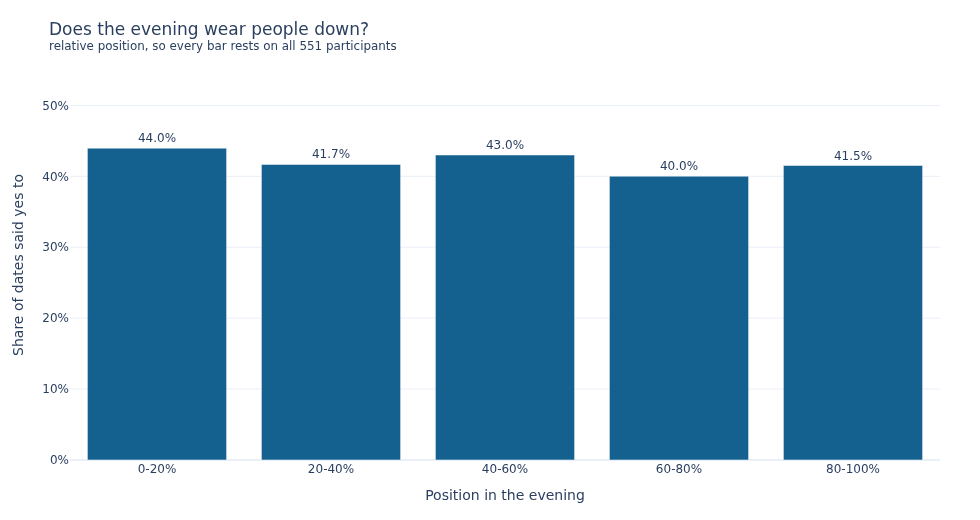

In [20]:
plot_data = binned.reset_index(names='position')

fig = px.bar(plot_data, x='position', y='yes_rate',
             text='yes_rate',
             labels={'position': 'Position in the evening', 'yes_rate': 'Share of dates said yes to'},
             title='Does the evening wear people down?'
                   '<br><sup>relative position, so every bar rests on all 551 participants</sup>')
fig.update_traces(texttemplate='%{text:.1%}', textposition='outside', marker_color='#14618F')
fig.update_yaxes(tickformat='.0%', range=[0, 0.55])
show(fig, '4_5_relative_position')

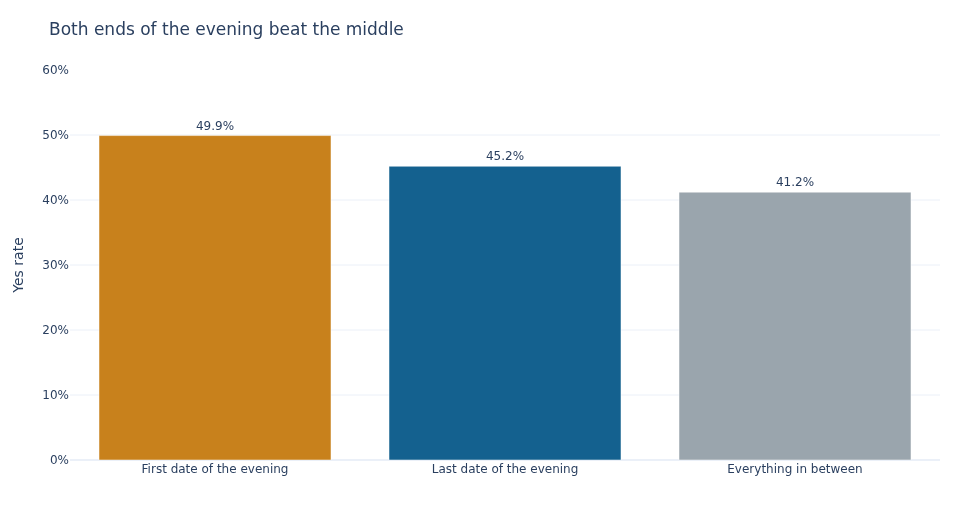

                 Position  Yes rate
First date of the evening     0.499
 Last date of the evening     0.452
    Everything in between     0.412


In [21]:
# The one comparison the wave-length problem does not affect: first against last, computed
# within each participant. Both dates belong to the same person and the same evening.
by_person = timed.sort_values(['iid', 'order']).groupby('iid')['dec']
first_last = pd.DataFrame({
    'Position': ['First date of the evening', 'Last date of the evening', 'Everything in between'],
    'Yes rate': [by_person.first().mean(),
                 by_person.last().mean(),
                 timed[(timed['order'] > 1) & (timed['order'] < timed['round'])]['dec'].mean()],
})

fig = px.bar(first_last, x='Position', y='Yes rate', color='Position', text='Yes rate',
             color_discrete_sequence=['#C8811C', '#14618F', '#9AA5AD'],
             title='Both ends of the evening beat the middle')
fig.update_traces(texttemplate='%{text:.1%}', textposition='outside')
fig.update_yaxes(tickformat='.0%', range=[0, 0.6])
fig.update_layout(showlegend=False, xaxis_title='')
show(fig, '4_5_first_vs_last')

print(first_last.round(3).to_string(index=False))

**Corrected, the fatigue curve disappears.** On relative position the yes-rate goes 44.0%, 41.7%,
43.0%, 40.0%, 41.5% — a four-point spread with no trend. People are not gradually worn down by the
evening. The decline visible on raw `order` was largely the population changing underneath the
curve, not behaviour changing along it.

**What survives is that both ends of the evening beat the middle.** The very first date gets a yes
**49.9%** of the time and the very last **45.2%**, against **41.2%** for everything in between. So
the answer to the question as asked is **first, clearly** — 4.7 points ahead of last — but "last"
is not the worst place to be either. The worst place is the middle.

That shape is worth naming: it is not a decline, it is a **U**. A pure fatigue story predicts a
slope, and there is no slope — the relative-position bins are flat. A story where the ends are
simply more memorable predicts a U, and that is what the data shows.

**A plausible reading of the first-date premium is that it has no competition yet.** With nobody to
compare against, the participant has no scale and judges generously; the second date is already
measured against the first. That is a hypothesis this dataset is consistent with rather than one it
proves — the premium is clearly visible, but the experiment was not designed to isolate its cause,
and nothing here rules out the first partners simply having been more appealing.

**The practical consequence** for a product built on a queue of profiles is that position is not
neutral: the first profile shown is judged on different terms from the tenth.

---

# 5. What Tinder should take from this

### The four findings

**1. What people declare is a poor guide to what they choose — and women more than men.** Men
declare attractiveness first and use it first: no gap. Women declare it *third*, behind intelligence
and sincerity, and it drives their decisions more strongly than any other attribute. Intelligence
makes the opposite trip for both genders, from the top of the declared list to fourth or fifth in
practice. Two independent methods — correlation with the decision, and participants' own day-after
accounting, which moves attractiveness +8.3 points — agree on it.
*A stated-preference questionnaire is not a reliable input to a matching algorithm.*

**2. Perceived common ground predicts a second date. Actual common ground does not.** Interests
genuinely shared, measured before anyone met, correlate +0.019 with a yes — statistically
indistinguishable from sharing a racial background (+0.023), and both indistinguishable from
nothing. Interests *felt* to be shared during the conversation correlate +0.401. *The lever is not
better filtering upstream, it is helping two people find common ground while they talk.*

**3. Nobody knows what they are worth.** Participants rate themselves about a point above what the
room gives them, on every attribute, and 72% overestimate their own attractiveness. The bias is
uniform rather than concentrated on any particular trait, and the individual spread is larger than
the bias itself. *Self-declared profile attributes should be treated as aspiration, not measurement.*

**4. Position in the queue is not neutral, and the pattern is a U.** The first date of the evening
gets a yes 49.9% of the time and the last 45.2%, against 41.2% in between. Once relative position is
used instead of raw rank the apparent fatigue slope disappears entirely — what is left is that the
ends of the evening are judged more generously than the middle. *The first profile a user sees is
judged on different terms from the tenth.*

### What follows for the product

- **Stop weighting declared preferences.** They describe the person users believe they are looking
  for, and finding 2 shows the two barely overlap. Observed swipe behaviour is the better signal,
  and it is the one Tinder already has.
- **Invest in the conversation, not the filter.** Finding 2 is the strongest result in this
  notebook and it points away from matching criteria and toward the first exchange — prompts,
  icebreakers, anything that surfaces common ground rather than asserting it in advance.
- **Do not treat racial background as a matching signal.** It predicts a second date no better than
  chance. Using it would encode a preference the data does not support, with an obvious fairness
  cost and no measured benefit.
- **Treat queue position as a variable, not a detail.** If the first profile is judged generously,
  ordering is a product decision with measurable consequences, and it should be tested as one.

### What this data cannot tell us

Worth saying out loud before any of it reaches a roadmap:

- **It is twenty years old**, collected from Columbia graduate students between 2002 and 2004. That
  is not Tinder's user base in age, geography or background.
- **Four minutes face to face is not a swipe.** Everything here is measured after a conversation;
  Tinder's decision happens before one. Findings 1 and 3 transfer reasonably well because they are
  about self-knowledge. Findings 2 and 4 are about the encounter itself and transfer less directly.
- **The measured effects are small.** The strongest pre-event predictor in the whole dataset barely
  clears +0.02. Most of what decides a second date is not in these 195 columns.
- **Correlation, not causation.** Nothing here was randomised except the pairing.